In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

print(' Imports OK')

 Imports OK


In [2]:
df = pd.read_csv('../data/listings.csv')

print(f'Shape : {df.shape}')
df.head()


Shape : (12959, 79)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,6,https://www.airbnb.com/rooms/6,20250621143303,2025-06-23,city scrape,North Park Craftsmen House * Great for Families,This Beautiful Craftsman house has all the mod...,"We have the best Neighborhood in San Diego, in...",https://a0.muscache.com/pictures/miso/Hosting-...,29,https://www.airbnb.com/users/show/29,Sara,2008-03-03,"San Diego, CA",I am a San Diego based Entrepreneur with a lov...,within an hour,100%,94%,t,https://a0.muscache.com/im/pictures/user/User/...,https://a0.muscache.com/im/pictures/user/User/...,North Park,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,North Hills,NaN,32.755220,-117.128730,Entire home,Entire home/apt,7,2.0,2 baths,3.0,6.0,"[""Private backyard \u2013 Fully fenced"", ""Chil...",$303.00,2,30,2,2,1125,1125,2.0,1125.0,NaN,t,8,26,45,169,2025-06-23,187,34,7,140,12,204,61812.0,2008-06-22,2025-06-13,4.83,4.85,4.73,4.98,4.98,4.80,4.81,"STR-04545L, 631067",f,1,1,0,0,0.90
1,12447,https://www.airbnb.com/rooms/12447,20250621143303,2025-06-22,city scrape,Cozy Pacific Beach Hideaway!,Your San Diego hideaway awaits!<br /><br />Pri...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,48669,https://www.airbnb.com/users/show/48669,Jennifer,2009-10-27,"San Diego, CA",I like to meet new people. I enjoy cooking and...,within an hour,100%,100%,t,https://a0.muscache.com/im/users/48669/profile...,https://a0.muscache.com/im/users/48669/profile...,Pacific Beach,2.0,2.0,"['email', 'phone']",t,t,NaN,Pacific Beach,NaN,32.805330,-117.234000,Private room in condo,Private room,2,1.0,1 private bath,1.0,0.0,"[""Bed linens"", ""Microwave"", ""Hot water"", ""Kitc...",$82.00,6,365,6,6,365,365,6.0,365.0,NaN,t,0,0,28,303,2025-06-22,6,4,1,131,3,48,3936.0,2011-11-10,2025-05-23,4.83,4.33,5.00,5.00,5.00,4.83,4.67,"STR-06735L, 631362",f,2,0,2,0,0.04
2,29967,https://www.airbnb.com/rooms/29967,20250621143303,2025-06-22,city scrape,"Great home, 10 min walk to Beach","This 2 bedroom, 2 full bathroom home offers al...",NaN,https://a0.muscache.com/pictures/76103867/c9b5...,129123,https://www.airbnb.com/users/show/129123,Michael,2010-05-21,"San Diego, CA",We love living part of the year in San Diego. ...,within a few hours,100%,71%,t,https://a0.muscache.com/im/users/129123/profil...,https://a0.muscache.com/im/users/129123/profil...,Pacific Beach,5.0,9.0,"['email', 'phone', 'work_email']",t,t,NaN,Pacific Beach,NaN,32.807510,-117.257600,Entire bungalow,Entire home/apt,6,2.0,2 baths,2.0,3.0,"[""Dryer"", ""Hot water"", ""Long term stays allowe...",$243.00,4,365,2,4,365,365,4.0,365.0,NaN,t,7,20,41,300,2025-06-22,119,11,1,130,12,88,21384.0,2010-07-0

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12959 entries, 0 to 12958
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            12959 non-null  int64  
 1   listing_url                                   12959 non-null  str    
 2   scrape_id                                     12959 non-null  int64  
 3   last_scraped                                  12959 non-null  str    
 4   source                                        12959 non-null  str    
 5   name                                          12959 non-null  str    
 6   description                                   12791 non-null  str    
 7   neighborhood_overview                         7769 non-null   str    
 8   picture_url                                   12959 non-null  str    
 9   host_id                                       12959 non-null  int64  
 1

In [4]:
# Nettoyage de la colonne price
df['price'] = (
    df['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

print(df['price'].head())
print(df['price'].dtype)

0    303.0
1     82.0
2    243.0
3     94.0
4    108.0
Name: price, dtype: float64
float64


In [5]:
na_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

na_df = pd.DataFrame({
    'missing_%': na_percent
})

na_df.head(20)

,missing_%
neighbourhood_group_cleansed,100.000000
calendar_updated,100.000000
neighborhood_overview,40.049387
host_about,40.049387
neighbourhood,40.049387
host_location,25.387761
license,21.452273
last_review,17.154101
reviews_per_month,17.154101
first_review,17.154101


In [6]:
cols_to_drop = [
    'id',
    'listing_url',
    'scrape_id',
    'last_scraped',
    'picture_url',
    'host_url',
    'host_thumbnail_url',
    'host_picture_url',
    'calendar_updated',
    'neighbourhood_group_cleansed',
    'license',
    'name',
    'description',
    'neighborhood_overview',
    'host_about'
]

df = df.drop(columns=cols_to_drop)

print(df.shape)

(12959, 64)


In [7]:
df = df.dropna(subset=['price'])

print(df.shape)

(11604, 64)


In [8]:
df['has_wifi'] = df['amenities'].str.contains('Wifi', case=False, na=False).astype(int)
df['has_tv'] = df['amenities'].str.contains('TV', case=False, na=False).astype(int)
df['has_kitchen'] = df['amenities'].str.contains('Kitchen', case=False, na=False).astype(int)
df['has_air_conditioning'] = df['amenities'].str.contains('Air conditioning', case=False, na=False).astype(int)
df['has_pool'] = df['amenities'].str.contains('Pool', case=False, na=False).astype(int)

df['has_elevator'] = df['amenities'].str.contains('Elevator', case=False, na=False).astype(int)
df['has_washer'] = df['amenities'].str.contains('Washer', case=False, na=False).astype(int)
df['has_dishwasher'] = df['amenities'].str.contains('Dishwasher', case=False, na=False).astype(int)
df['has_parking'] = df['amenities'].str.contains('Parking', case=False, na=False).astype(int)
df['has_heating'] = df['amenities'].str.contains('Heating', case=False, na=False).astype(int)
df['has_workspace'] = df['amenities'].str.contains('Dedicated workspace', case=False, na=False).astype(int)

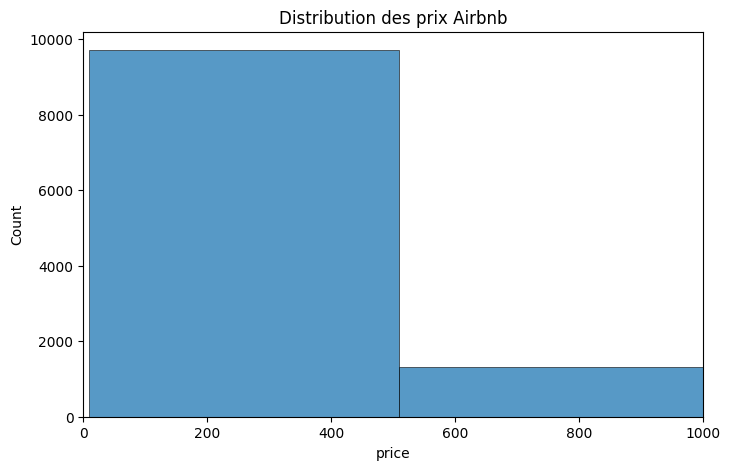

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], bins=100)

plt.title('Distribution des prix Airbnb')
plt.xlim(0, 1000)

plt.show()

Montrer le problème de skewness

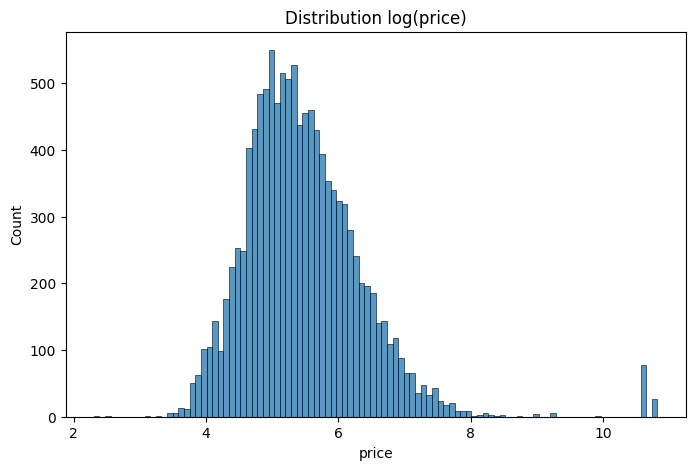

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df['price']), bins=100)

plt.title('Distribution log(price)')
plt.show()

"""
Observations :

- La distribution du prix est fortement asymétrique à droite.
- Quelques logements de luxe créent des outliers très élevés.
- Une transformation logarithmique semble nécessaire.
- Les équipements comme Wifi et climatisation semblent fréquents.
- Beaucoup de valeurs manquantes existent dans les reviews et informations host.
"""

ÉTAPE 9 — Choisir les features

IMPORTANT : ne prends PAS les 70 colonnes sinon ça devient ingérable.

Prends une sélection propre.

## Filtrer les outliers de prix

La distribution du prix a une longue queue (logements > 1 000 €/nuit). Conformément à la limite documentée dans le README, on filtre `10 € ≤ price ≤ 1 000 €` pour que les modèles linéaires n'explosent pas sur les extrêmes.

In [11]:
before = len(df)
df = df[df['price'].between(10, 1000)].reset_index(drop=True)
after = len(df)
print(f'Lignes filtrées : {before - after} ({(before - after) / before:.1%})')
print(f'Lignes restantes : {after}')

Lignes filtrées : 579 (5.0%)
Lignes restantes : 11025


In [12]:
# Feature engineering
df['price_per_person'] = df['price'] / df['accommodates'].replace(0, 1)

df['bathrooms_per_bedroom'] = df['bathrooms'] / df['bedrooms'].replace(0, 1)

df['host_seniority_days'] = (
    pd.Timestamp.today() - pd.to_datetime(df['host_since'])
).dt.days

print('Features engineered :', ['price_per_person', 'bathrooms_per_bedroom', 'host_seniority_days'])

Features engineered : ['price_per_person', 'bathrooms_per_bedroom', 'host_seniority_days']


In [13]:
selected_features = [
    'host_response_rate',
    'host_acceptance_rate',
    'host_is_superhost',
    'neighbourhood_cleansed',
    'property_type',
    'room_type',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'number_of_reviews',
    'review_scores_rating',
    'reviews_per_month',
    'availability_365',
    'latitude',
    'longitude',
    'bathrooms_per_bedroom',
    'host_seniority_days',

    # amenities
    'has_wifi',
    'has_tv',
    'has_kitchen',
    'has_air_conditioning',
    'has_pool',
    'has_elevator',
    'has_washer',
    'has_dishwasher',
    'has_parking',
    'has_heating',
    'has_workspace',
]

X = df[selected_features].copy()
y = df['price']

ÉTAPE 10 — Nettoyer les %

Ces colonnes sont encore en string :

100%

Il faut convertir.

In [14]:
for col in ['host_response_rate', 'host_acceptance_rate']:

    X[col] = (
        X[col]
        .astype(str)
        .str.replace('%', '', regex=False)
    )

    X[col] = pd.to_numeric(X[col], errors='coerce')

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(X_train.shape)
print(X_test.shape)

(8820, 30)
(2205, 30)


In [16]:
num_cols = [
    'host_response_rate',
    'host_acceptance_rate',
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'minimum_nights',
    'number_of_reviews',
    'review_scores_rating',
    'reviews_per_month',
    'availability_365',
    'latitude',
    'longitude',
    'bathrooms_per_bedroom',
    'host_seniority_days',
]

cat_cols = [
    'host_is_superhost',
    'neighbourhood_cleansed',
    'property_type',
    'room_type',
]

amenities_cols = [
    'has_wifi',
    'has_tv',
    'has_kitchen',
    'has_air_conditioning',
    'has_pool',
    'has_elevator',
    'has_washer',
    'has_dishwasher',
    'has_parking',
    'has_heating',
    'has_workspace',
]

In [17]:
preprocessor = ColumnTransformer(
    [
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols),

        ('amenities', 'passthrough', amenities_cols),
    ],
    sparse_threshold=0,  # HistGradientBoosting requires dense input
)

In [18]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'RandomForest': RandomForestRegressor(random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
}

In [19]:
from sklearn.compose import TransformedTargetRegressor
results = []

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

for name, model in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', TransformedTargetRegressor(
            regressor=model,
            func=np.log1p,
            inverse_func=np.expm1
        ))
    ])

    mae_scores = -cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=kf,
        scoring='neg_mean_absolute_error'
    )

    r2_scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=kf,
        scoring='r2'
    )

    results.append({
        'Model': name,
        'MAE mean': mae_scores.mean(),
        'MAE std': mae_scores.std(),
        'R2 mean': r2_scores.mean(),
        'R2 std': r2_scores.std()
    })

results_df = pd.DataFrame(results)

results_df

,Model,MAE mean,MAE std,R2 mean,R2 std
0,LinearRegression,71.813811,2.108725,0.612125,0.023212
1,Ridge,71.830690,2.031307,0.611390,0.022675
2,RandomForest,63.374521,1.677344,0.707261,0.007593
3,GradientBoosting,65.817544,1.570966,0.687482,0.008852
4,HistGradientBoosting,61.677708,1.755828,0.730774,0.011815


## Tuning du meilleur modèle — RandomizedSearchCV

On optimise le RandomForest avec une recherche aléatoire sur 20 combinaisons (cv=3).

In [20]:
param_dist = {
    'model__regressor__n_estimators': [200, 300, 500],
    'model__regressor__max_depth': [None, 10, 20, 30],
    'model__regressor__min_samples_leaf': [1, 2, 4],
    'model__regressor__max_features': ['sqrt', 0.3, 0.5],
}

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', TransformedTargetRegressor(
        regressor=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

search.fit(X_train, y_train)

print('Meilleurs paramètres :', search.best_params_)
print(f'Meilleur score CV (MAE) : {-search.best_score_:.2f} €')

Fitting 3 folds for each of 20 candidates, totalling 60 fits


Meilleurs paramètres : {'model__regressor__n_estimators': 300, 'model__regressor__min_samples_leaf': 1, 'model__regressor__max_features': 0.3, 'model__regressor__max_depth': None}
Meilleur score CV (MAE) : 63.55 €


## Évaluation finale sur le test set

On évalue le modèle tuné (issu du RandomizedSearchCV) sur le test set.

In [21]:
best_pipe = search.best_estimator_

y_pred = best_pipe.predict(X_test)

mae_test = mean_absolute_error(y_test, y_pred)
rmse_test = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2_test = r2_score(y_test, y_pred)

print(f'MAE test  : {mae_test:.2f} €')
print(f'RMSE test : {rmse_test:.2f} €')
print(f'R² test   : {r2_test:.4f}')

MAE test  : 63.07 €
RMSE test : 103.45 €
R² test   : 0.7344


## Analyse des résidus

- À gauche : résidu (y - ŷ) vs prix prédit. Une bande horizontale autour de 0 = bon signe.
- À droite : distribution des résidus. Centrée sur 0 = pas de biais global.

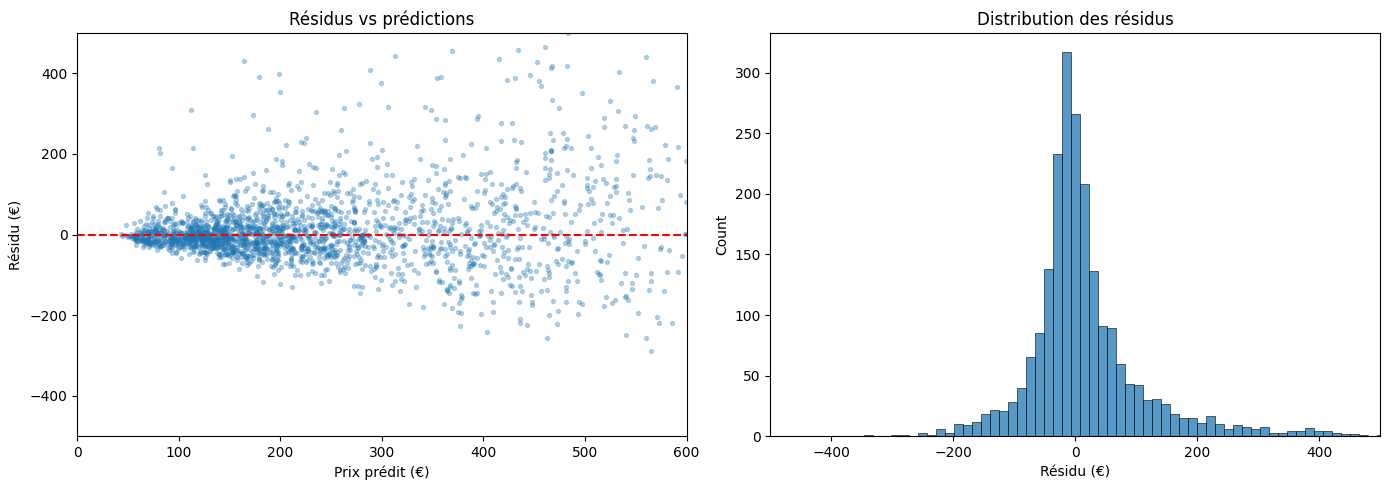

Résidu moyen   : 16.89 €
Résidu médian  : -2.41 €
Résidu |moyen| : 63.07 €


In [22]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, residuals, alpha=0.3, s=8)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Prix prédit (€)')
axes[0].set_ylabel('Résidu (€)')
axes[0].set_title('Résidus vs prédictions')
axes[0].set_xlim(0, 600)
axes[0].set_ylim(-500, 500)

sns.histplot(residuals, bins=80, ax=axes[1])
axes[1].set_xlim(-500, 500)
axes[1].set_title('Distribution des résidus')
axes[1].set_xlabel('Résidu (€)')

plt.tight_layout()
plt.show()

print(f'Résidu moyen   : {residuals.mean():.2f} €')
print(f'Résidu médian  : {residuals.median():.2f} €')
print(f'Résidu |moyen| : {residuals.abs().mean():.2f} €')

## Export du modèle et des métriques

In [23]:
import os

os.makedirs('../outputs', exist_ok=True)

joblib.dump(best_pipe, '../outputs/model.joblib')

metrics = {
    'model': 'RandomForestRegressor wrapped in TransformedTargetRegressor(log1p / expm1)',
    'features': selected_features,
    'cv_results': results_df.to_dict(orient='records'),
    'test_mae': float(mae_test),
    'test_rmse': float(rmse_test),
    'test_r2': float(r2_test),
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
}

with open('../outputs/metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print('Saved -> outputs/model.joblib')
print('Saved -> outputs/metrics.json')

Saved -> outputs/model.joblib
Saved -> outputs/metrics.json


## Démo — prédire le prix pour un logement concret

In [24]:
sample = pd.DataFrame([{
    'host_response_rate': 100,
    'host_acceptance_rate': 95,
    'host_is_superhost': 't',
    'neighbourhood_cleansed': 'Buttes-Montmartre',
    'property_type': 'Entire rental unit',
    'room_type': 'Entire home/apt',
    'accommodates': 4,
    'bathrooms': 1.0,
    'bedrooms': 2,
    'beds': 2,
    'minimum_nights': 2,
    'number_of_reviews': 50,
    'review_scores_rating': 4.8,
    'reviews_per_month': 2.5,
    'availability_365': 200,
    'latitude': 48.8867,
    'longitude': 2.3431,
    'bathrooms_per_bedroom': 0.5,
    'host_seniority_days': 1825,
    'has_wifi': 1,
    'has_tv': 1,
    'has_kitchen': 1,
    'has_air_conditioning': 1,
    'has_pool': 0,
    'has_elevator': 1,
    'has_washer': 1,
    'has_dishwasher': 0,
    'has_parking': 0,
    'has_heating': 1,
    'has_workspace': 1,
}])

predicted_price = float(best_pipe.predict(sample)[0])
print(f'Logement : 2 chambres à Montmartre, 4 personnes, équipé')
print(f'Prix prédit : {predicted_price:.2f} €/nuit')

Logement : 2 chambres à Montmartre, 4 personnes, équipé
Prix prédit : 165.75 €/nuit
